# 2. LSTM AutoEncoder (Sliding Window without Feature Engineering)



In [52]:
import pandas as pd

Data = pd.read_csv("../data/processed/Cleaned-Vehicle-Health-Telemetry-Dataset.csv")
Data.head()

,Timestamp,Engine_RPM,Vehicle_Speed,Coolant_Temp,Oil_Pressure,Vibration_Z,Engine_Load,Fuel_Rate,Intake_Air_Temp,Battery_Voltage,Throttle_Position,Ambient_Temp,Brake_Pressure,Acceleration_X,Acceleration_Y,Fault_Label,Fault_Type
0,2026-06-01 00:00:00,0.0,0.0,21.259663,1.661008,0.013402,0.0,0.0,21.933113,12.488478,0.0,21.446732,0.5,0.0,0.0,0.0,Normal
1,2026-06-01 00:00:01,0.0,0.0,21.259663,1.653945,0.012205,0.0,0.0,21.702260,12.488286,0.0,21.408633,0.5,0.0,0.0,0.0,Normal
2,2026-06-01 00:00:02,0.0,0.0,21.305162,1.453309,0.013224,0.0,0.0,21.794081,12.490938,0.0,21.425312,0.5,0.0,0.0,0.0,Normal
3,2026-06-01 00:00:03,0.0,0.0,21.384146,1.384312,0.013470,0.0,0.0,21.508731,12.497744,0.0,21.491175,0.5,0.0,0.0,0.0,Normal
4,2026-06-01 00:00:04,0.0,0.0,21.387741,1.865632,0.010776,0.0,0.0,21.785657,12.496880,0.0,21.438434,0.5,0.0,0.0,0.0,Normal


In [53]:

import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

columns_to_drop = ["Timestamp", "Fault_Label", "Fault_Type"]
X_Features = Data.drop(columns=columns_to_drop)

X_train, X_test = train_test_split(X_Features, test_size = 0.2, shuffle = False)

scaler = MinMaxScaler()
X_train_Scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.transform(X_test)

def create_sequences(data, time_steps):
    Xs, ys = [], []
    for i in range(len(data) - time_steps):
        Xs.append(data[i:(i + time_steps)])
        ys.append(data[i:(i + time_steps)])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 10

X_train_Seq, Y_train_Seq = create_sequences(X_train_Scaled, TIME_STEPS)
X_test_Seq, Y_test_Seq = create_sequences(X_test_Scaled, TIME_STEPS)

print(f"Training shape: {X_train_Seq.shape}")
print(f"Testing shape: {X_test_Seq.shape}")

Training shape: (483830, 10, 14)
Testing shape: (120950, 10, 14)


In [54]:
import torch
import torch.nn as nn

class LSTMAutoEncoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=16, hidden_dim=64):
        super(LSTMAutoEncoder, self).__init__()
        self.seq_len = seq_len
        self.n_features = n_features
        self.hidden_dim = hidden_dim
        self.embedding_dim = embedding_dim

        self.encoder_lstm1 = nn.LSTM(input_size=n_features, hidden_size=hidden_dim, num_layers=1, batch_first=True)
        self.encoder_lstm2 = nn.LSTM(input_size=hidden_dim, hidden_size=embedding_dim, num_layers=1, batch_first=True)

        self.decoder_lstm1 = nn.LSTM(input_size=embedding_dim, hidden_size=embedding_dim, num_layers=1, batch_first=True)
        self.decoder_lstm2 = nn.LSTM(input_size=embedding_dim, hidden_size=hidden_dim, num_layers=1, batch_first=True)

        self.output_layer = nn.Linear(hidden_dim, n_features)

    def forward(self, x):
        x, _ = self.encoder_lstm1(x)
        _, (hidden, _) = self.encoder_lstm2(x)
        
        hidden = hidden[-1].unsqueeze(1).repeat(1, self.seq_len, 1)

        x, _ = self.decoder_lstm1(hidden)
        x, _ = self.decoder_lstm2(x)

        out = self.output_layer(x)
        return out

In [55]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device :", device)

time_steps = X_train_Seq.shape[1]
features = X_train_Seq.shape[2]

Model = LSTMAutoEncoder(seq_len = time_steps, n_features = features, hidden_dim = 64).to(device)
print(Model)

Using Device : cuda
LSTMAutoEncoder(
  (encoder_lstm1): LSTM(14, 64, batch_first=True)
  (encoder_lstm2): LSTM(64, 16, batch_first=True)
  (decoder_lstm1): LSTM(16, 16, batch_first=True)
  (decoder_lstm2): LSTM(16, 64, batch_first=True)
  (output_layer): Linear(in_features=64, out_features=14, bias=True)
)


In [56]:

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
import time
from tqdm import tqdm

X_train_tensor = torch.tensor(X_train_Seq, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_Seq, dtype=torch.float32)

batch_size = 256

train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, X_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

criterion = nn.MSELoss()
optimizer = optim.Adam(Model.parameters(), lr=0.001)

epochs = 15
train_loss = []
val_loss = []

print("Start Training...")
for epoch in range(epochs):
    start_time = time.time()

    Model.train()
    running_loss = 0.0

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{epochs} [Train]", leave=False)
    for batch_x, batch_y in train_loop:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = Model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_x.size(0)
        train_loop.set_postfix(loss=loss.item())

    Model.eval()
    val_running_loss = 0.0
    
    with torch.no_grad():
        val_loop = tqdm(test_loader, desc=f"Epoch {epoch+1:02d}/{epochs} [Val]", leave=False)
        for batch_x, batch_y in val_loop:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = Model(batch_x)
            
            loss = criterion(outputs, batch_y)
            
            val_running_loss += loss.item() * batch_x.size(0)
            val_loop.set_postfix(loss=loss.item())
    
    epoch_train_loss = running_loss / len(X_train_tensor)
    epoch_val_loss = val_running_loss / len(X_test_tensor)
    
    train_loss.append(epoch_train_loss)
    val_loss.append(epoch_val_loss)
    
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1:02d}/{epochs} | Time: {epoch_time:.1f}s | Train Loss: {epoch_train_loss:.5f} | Val Loss: {epoch_val_loss:.5f}")

print("Training Completed!")

Start Training...


Epoch 01/15 | Time: 20.4s | Train Loss: 0.00345 | Val Loss: 0.00382


Epoch 02/15 | Time: 20.5s | Train Loss: 0.00025 | Val Loss: 0.00173


Epoch 03/15 | Time: 20.5s | Train Loss: 0.00014 | Val Loss: 0.00123


Epoch 04/15 | Time: 20.4s | Train Loss: 0.00010 | Val Loss: 0.00111


...

Epoch 11/15 | Time: 20.9s | Train Loss: 0.00006 | Val Loss: 0.00085


Epoch 12/15 | Time: 21.0s | Train Loss: 0.00005 | Val Loss: 0.00084


Epoch 13/15 | Time: 20.9s | Train Loss: 0.00005 | Val Loss: 0.00078


Epoch 14/15 | Time: 21.0s | Train Loss: 0.00005 | Val Loss: 0.00079


Epoch 15/15 | Time: 21.3s | Train Loss: 0.00005 | Val Loss: 0.00076
Training Completed!


In [60]:

import numpy as np

def get_reconstruction_errors(Model, data_loader):
    Model.eval()
    errors = []
    
    loop = tqdm(data_loader, desc="Calculating Errors", leave=False)
    
    with torch.no_grad():
        for batch_x, _ in loop:
            batch_x = batch_x.to(device)
            
            reconstructed = Model(batch_x)
            
            loss = torch.abs(reconstructed - batch_x)
            
            sample_errors = loss.mean(dim=[1, 2]).cpu().numpy()
            errors.extend(sample_errors)
            
    return np.array(errors)

print("Calculating errors for Training set...")
train_errors = get_reconstruction_errors(Model, train_loader)

print("Calculating errors for Testing set...")
test_errors = get_reconstruction_errors(Model, test_loader)

print(f"Average Train Error: {np.mean(train_errors):.5f}")
print(f"Average Test Error: {np.mean(test_errors):.5f}")
print(f"Max Train Error: {np.max(train_errors):.5f}")
print(f"Max Test Error: {np.max(test_errors):.5f}")

Calculating errors for Training set...


Calculating errors for Testing set...


Average Train Error: 0.00332
Average Test Error: 0.00956
Max Train Error: 0.07323
Max Test Error: 0.08006


In [75]:

import pandas as pd


torch.save(Model.state_dict(), 'lstm_autoencoder_model.pth')
print("✅ Model weights saved successfully to 'lstm_autoencoder_model.pth'")


test_timestamps = Data.index[-len(test_errors):]

threshold = float(np.mean(train_errors) + 3 * np.std(train_errors))

results_df = pd.DataFrame({
    'Timestamp': test_timestamps,
    'LSTM_Error': test_errors,
    'LSTM_Anomaly_Flag': (test_errors > threshold).astype(int)
})

results_df.to_csv('LSTM_Anomaly_Results.csv', index=False)
print("✅ Results saved successfully to 'LSTM_Anomaly_Results.csv'")

✅ Model weights saved successfully to 'lstm_autoencoder_model.pth'
✅ Results saved successfully to 'LSTM_Anomaly_Results.csv'


Anomaly Threshold: 0.01156


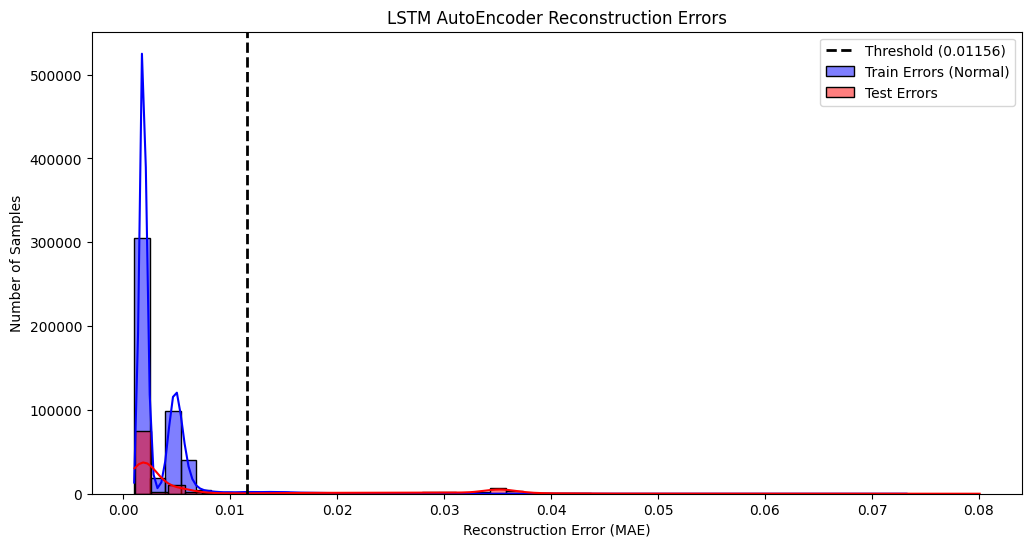

In [65]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

threshold = float(np.mean(train_errors) + 3 * np.std(train_errors))
print(f"Anomaly Threshold: {threshold:.5f}")

plt.figure(figsize=(12, 6))

sns.histplot(train_errors, bins=50, kde=True, color='blue', alpha=0.5, label='Train Errors (Normal)')

sns.histplot(test_errors, bins=50, kde=True, color='red', alpha=0.5, label='Test Errors')

plt.axvline(threshold, color='black', linestyle='dashed', linewidth=2, label=f'Threshold ({threshold:.5f})')

plt.title("LSTM AutoEncoder Reconstruction Errors")
plt.xlabel("Reconstruction Error (MAE)")
plt.ylabel("Number of Samples")
plt.legend()
plt.show()

In [74]:
import torch

normal_reading = X_train_Seq[0].copy()

abnormal_reading = normal_reading.copy()
abnormal_reading[:, 3] = 0.1  # Inject an extreme value into sensor 3
abnormal_reading[:, 5] = 0.1  # Inject an extreme value into sensor 5

normal_tensor = torch.tensor(normal_reading, dtype=torch.float32).unsqueeze(0).to(device)
abnormal_tensor = torch.tensor(abnormal_reading, dtype=torch.float32).unsqueeze(0).to(device)

Model.eval()
with torch.no_grad():
    # Test the normal condition
    rec_normal = Model(normal_tensor)
    error_normal = torch.abs(rec_normal - normal_tensor).mean().item()
    
    # Test the abnormal condition
    rec_abnormal = Model(abnormal_tensor)
    error_abnormal = torch.abs(rec_abnormal - abnormal_tensor).mean().item()

print("=== Anomaly Simulation (Live Test) ===")
print(f"Anomaly Threshold: {threshold:.5f}\n")

print(f"Reconstruction Error (Normal Condition): {error_normal:.5f}")
if error_normal > threshold:
    print("🚨 Result: The model detected an anomaly!")
else:
    print("✅ Result: The vehicle is operating normally.")

print("-" * 40)

print(f"Reconstruction Error (Simulated Anomaly): {error_abnormal:.5f}")
if error_abnormal > threshold:
    print("🚨 Result: The model successfully detected the anomaly!")
else:
    print("✅ Result: The vehicle is operating normally.")

=== Anomaly Simulation (Live Test) ===
Anomaly Threshold: 0.01156

Reconstruction Error (Normal Condition): 0.00215
✅ Result: The vehicle is operating normally.
----------------------------------------
Reconstruction Error (Simulated Anomaly): 0.01514
🚨 Result: The model successfully detected the anomaly!
